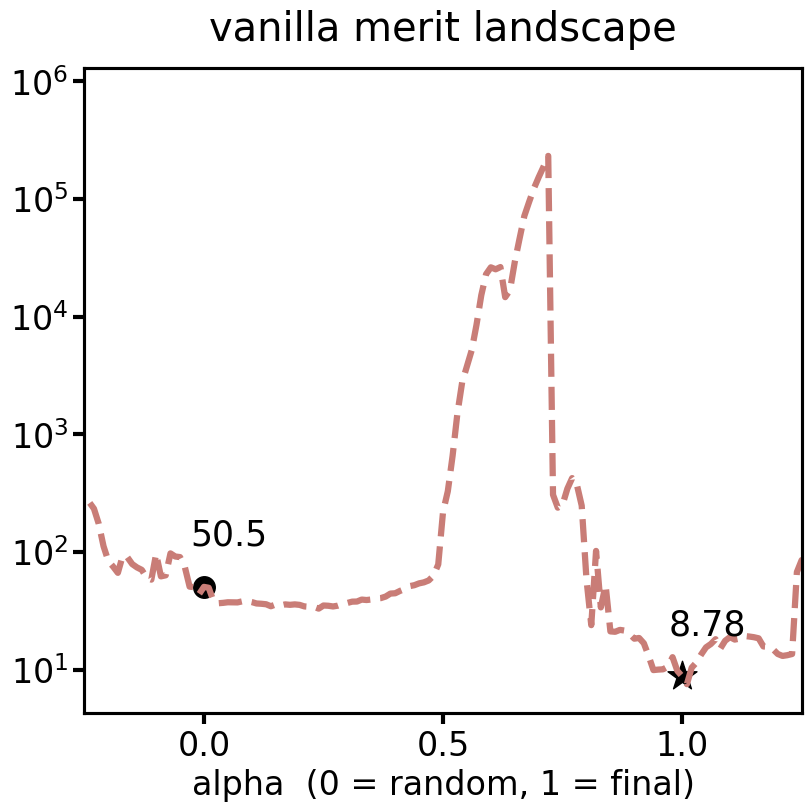

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt

SKIP = 1 # skip_first
LINE_WIDTH = 3
BASE_SIZE = 24
# Professional colors
COLORS = {
    "vanilla": "#C97D77",     # muted brick red
    "pretraining": "#3E6E9E", # steel blue
    "ours": "#6E8F71",        # sage green (updated)
}

def plot_merit_interpolation(
    t,
    merit,
    *,
    title="vanilla merit landscape",
    xlabel="alpha  (0 = random, 1 = final)",
    ylabel="merit value",
    save_path=None,
    dpi=300,
    show=True,
    close=True,
):
    fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)

    A_idx = int((0.5 + 0.0) / 2 * 200)
    B_idx = int((0.5 + 1.0) / 2 * 200)

    ax.plot(t, merit, linewidth=LINE_WIDTH * 1.5, color=COLORS['vanilla'], linestyle='--')
    ax.scatter([0.0], [(merit[A_idx])], s=BASE_SIZE*10, marker='o', color='black')
    ax.scatter([1.0], [(merit[B_idx])], s=BASE_SIZE*20, marker='*', color='black')

    ax.set_title(title, fontsize=BASE_SIZE * 1.2, pad=20)
    ax.set_xlabel(xlabel, fontsize=BASE_SIZE, fontweight='normal')
    ax.set_xlim(-0.25, 1.25)
    # ax.set_ylabel(ylabel, fontsize=BASE_SIZE, fontweight='normal')
    # ax.set_ylim(-10, 1.5e5)
    ax.set_yscale("log")
    
    ax.minorticks_off()
    ax.locator_params(axis='x', nbins=4)
    ax.tick_params(axis='both', labelsize=BASE_SIZE, width=LINE_WIDTH, length=8, color='black')

    # ax.grid(True, alpha=0.3)

    # annotate endpoints
    ax.annotate(f"{(merit[A_idx]):.3g}", (t[A_idx], merit[A_idx]), textcoords="offset points", xytext=(-10, 30),fontsize=BASE_SIZE+1)
    ax.annotate(f"{(merit[B_idx]):.3g}", (t[B_idx], merit[B_idx]), textcoords="offset points", xytext=(-10, 30), fontsize=BASE_SIZE+1)

    for spine in ax.spines.values():
        spine.set_linewidth(LINE_WIDTH * 0.75)
        spine.set_color('black')

    # if save_path is not None:
    #     out_dir = os.path.dirname(save_path)
    #     if out_dir:
    #         os.makedirs(out_dir, exist_ok=True)
    #     fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    #     print(f"Saved plot to: {save_path}", flush=True)

    if show:
        plt.show()

    if close:
        plt.close(fig)


if __name__ == "__main__":
    # Load from the NPZ you saved earlier
    npz_path = "figures/merit_interpolation_random_to_vanilla.npz"  # EDIT if needed
    # npz_path = "figures/merit_interpolation_A_to_B.npz"  # EDIT if needed
    # npz_path = "figures/merit_interpolation_warmstarted.npz"  # EDIT if needed
    data = np.load(npz_path)

    t = data["t"]
    merit = data["merit"]

    plot_merit_interpolation(
        t,
        merit,
        show=True,   # set True if you want interactive display
    )
